**3장 - 분류**

# 설정

파이썬 3.7 또는 그 이상이 필요함 :

In [ ]:
import sys

assert sys.version_info >= (3, 7)

Scikit-Learn ≥1.0.1이 필요함 :

In [1]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

그래프를 보기 좋게 그리기 위해 기본 폰트 크기 설정 : 

In [2]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

`images/classification` 폴더가 없다면 이 폴더를 만들고 고해상도 이미지 저장을 위해 노트북에서 사용할 `save_fig()` 함수를 정의:

In [3]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# MNIST

OpenML.org에서 MNIST 데이터셋 다운

In [4]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

c:\Users\SSAFY\Desktop\dy\.venv\Lib\site-packages\sklearn\datasets\_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


fetch_, load_, make_ 함수로 생성된 데이터셋을 참조하는 딕셔너리

- DESCR : 데이터셋 설명

- data : 입력 데이터, 일반적으로 2D 넘파이 배열

- target : 레이블, 일반적으로 1D 넘파이 배열

In [5]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [6]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [7]:
X, y = mnist.data, mnist.target
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [8]:
X.shape

(70000, 784)

In [9]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [10]:
y.shape

(70000,)

In [11]:
28 * 28

784

이미지가 70,000개, 특성 784개(이미지가 28 * 28 이기 때문)

각 특성은 0(흰색) ~ 255(검정색)으로 픽셀의 강도를 나타냄

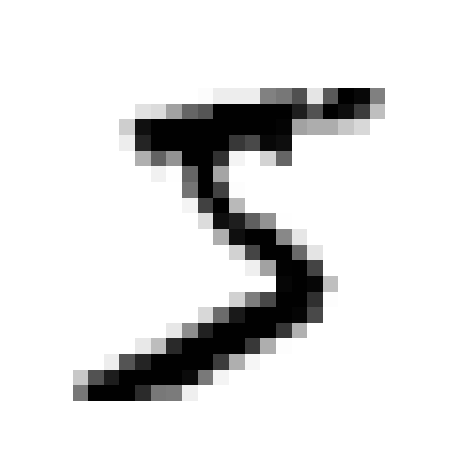

In [12]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
save_fig("some_digit_plot")
plt.show()

In [13]:
y[0]

'5'

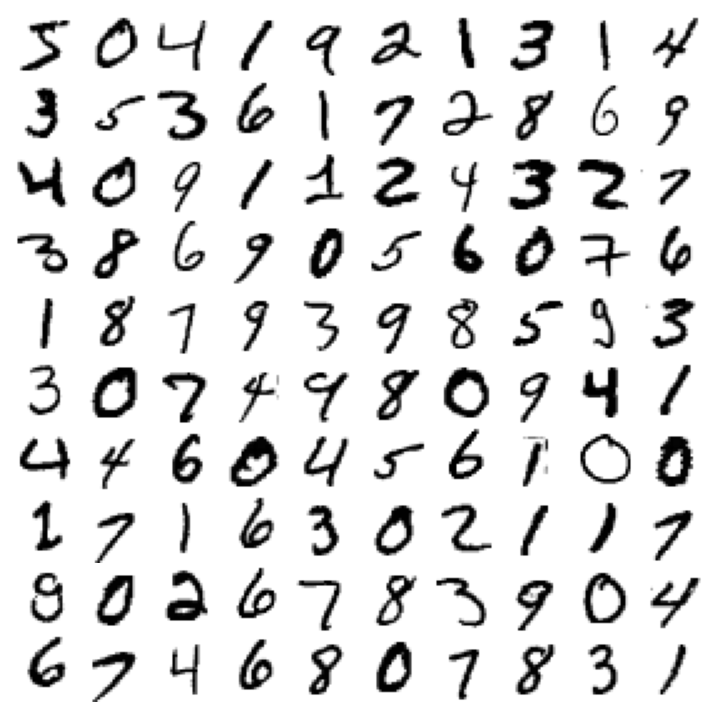

In [14]:
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
save_fig("more_digits_plot", tight_layout=False)
plt.show()

데이터를 자세히 조사하기 전에 항상 테스트 세트를 만들고 따로 떼어놓아야함.

fetch_openml()이 반환한 MNIST 데이터셋으 ㄴ이미 훈련 세트와 테스트 세트로 나누어져 있음.

In [15]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# 이진 분류기 훈련

문제를 단순화해서 하나의 숫자, 예를 들어 숫자 5만 식별해보겠음.

이 '5-감지기'는 '5'와 '5 아님' 두 개의 클래스를 구분할 수 있는 **이진 분류기(binary classifier)** 임.

분류 작업을 위해 타깃 벡터 생성

In [16]:
y_train_5 = (y_train == '5') # 5는 True, 다른 숫자는 False
y_test_5 = (y_test == '5')

이제  분류 모델을 하나 선택해서 훈련시켜야함. 사이킷런 `SGDClassifier`클래스를 사용해 **확률적 경사 하강법(Stochastic Gradient Descent, SGD)** 분류기로 시작하면 좋음. 

장점 : 
- 매우 큰 데이터셋을 효율적을 처리할 수 있음
- SGD는 한 번에 하나씩 훈련 샘플을 독립적으로 치리 가능

SGDClassifier 모델을 만들고 전체 훈련 세트를 활용해 학습하는 코드 :

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

이제 이 모델을 사용해 숫자 5의 이미지를 감지하는 코드 :

In [18]:
sgd_clf.predict([some_digit])

array([ True])

# 성능  측정

분류기 평가는 회귀 모델보다 훨씬 어려움.

## 교차 검증을 사용한 정확도 측정

cross_val_score() 함수로 폴드가 3개인 k-폴드 교차검증을 사용해 SGDClassifier 모델을 평가하는 코드 : 

In [20]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [21]:
# 추가적인 코드 - 교차 검증 구현


from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3)  # 데이터셋이 미리 섞여 있지 않다면
                                       # shuffle=True를 추가하세요.
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.95035
0.96035
0.9604


교차 검증 폴드에 대한 **정확도(Accuracy, 정확한 예측의 비율)**가 95% 이상임.

모든 이미지를 가장 많이 등장하는 클래스(여기서는 음성 클래스, 즉 '5' 아님)로 분류하는 더미 분류기를 만들어 비교

In [22]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


False가 출력됨. 즉, True로 예측된 것이 없음.

In [23]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

정확도가 90% 이상이 나옴. 이미지의 10% 정도만 숫자 5이기 때문에 무조건 '5아님' 으로 예측하면 정확히 맞출 확률이 90% 임.

이 예제는 정확도를 분류기의 성능 측정 지표로 선호하지 않는 이유를 보여줌. 

특히 **불균형한 데이터셋**을 다룰 때 (즉, 어떤 클래스가 다른 것보다 월등히 많은 경우) 더욱 그럼. 

분류기의 성능을 평가하는 더 좋은 방법은 **오차 행렬(confusion matrix)** 을 조사하는 것임.

## 오차 행렬

오차 행렬의 기본 아이디어는 모든 A/B 쌍에 대해 클래스 A의 샘플이 클래스 B로 분류된 횟수를 세는 것

오차 행렬을 만들려면 실제 타깃과 비교할 수 있도록 예측값을 만들어야함.


테스트 세트로 예측을 만들 수 있지만 여기서 사용하면 안됨. (테스트 세트는 프로젝트의 맨 마지막에 분류기가 출시 준비를 마치고 나서 사용된다는 것을 알아야함)

대신 cross_val_predict() 함수를 사용할 수 있음

In [24]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]], dtype=int64)

오차 행렬의 행은 **실제 클래스** 를 나타내고 열은 **예측한 클래스** 를 나타냅니다. 

이 행렬의 첫번째 행은 '5 아님' 이미지 (**음성 클래스 (negative class)**)에 대한 것으로, 53,892개를 '5 아님'으로 정확하게 분류했고(**음성 클래스(true negative)**이라고 함). 

나머지 687개는 '5'라고잘못 분류했음.(**거짓 양성(false positive)** 또는 **1종 오류(type 1 error)**라고 부름). 

두 번째 행은 '5'이미지 (**양성 클래스(positive c
lass)**) 에 대한 것으로, 1,897개를 '5 아님'으로 잘못 분류했고 (**거짓 음성(false negative)** 또는 **2종 오류(type 2 error)**라고 부름) 

나머지 3,530개를 정확히 '5'라고 분류했음(**진짜 양성(true positive)**이라고 함).

완벽한 분류기라면 진짜 양성과 진짜 음성만 가지고 있을 것이므로 오차 행렬의 주대각선 (왼쪽 위에서 오른쪽 아래로)만 0이 아닌 값이 됨.

In [26]:
y_train_perfect_predictions = y_train_5  # 완벽한 분류기일 경우
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]], dtype=int64)

오차 행렬이 많은 정보를 제공해주지만 가끔 더 요약된 지표가 필요할 때가 있음.

살펴볼만한 것 하나는 양성 예측의 정확도임. 이를 분류기의 **정밀도(precision)** 라고 함.

$$
정밀도 = \frac{TP}{TP + FP}
$$

TP는 진짜 양성의 수이고, FP는 거짓 양성의 수임.

가장 간단한 방법은 제일 확신이 높은 샘플에 대해 양성 예측을 하고 나머지는 모두 음성 예측을 하는 분류기를 만드는 것. 

이 양성 예측이 맞는다면 분류기의 정밀도는 100%임. (정밀도는 = 1/1 = 100%), 당연히 이런 분류기는 다른 모든 양성 샘플을 무시하기 때문에 그리 유용하지 않음.

정밀도는 **재현율 (recall)**이라는 또 다른 지표와 같이 사용하는 것이 일반적임. 

재현율은 분류기가 정확하게 감지한 양성 샘플 비율로, **민감도 (sensitivity)** 또는 **진짜 양성 비율 (true positive rate,TPR)** 이라고 함,

$$
재현율 = \frac{TP}{TP+FN}
$$

FN은 거짓 음성의 수임.